# Session 3 — Demo 1: Honest statistics

**What this demo covers.** You can now compute any number from the tables. Which numbers should you *trust*? The rule of the evening:

**Distribution first. Number second.**

**How we work tonight.** Every block below is a small investigation, always in the same four steps — this is exactly the shape HW1 asks you for:

- ❓ **Question** — what someone actually wants to know
- 🔍 **What we'll do** — *hidden behind a triangle: think about it first, then open it* the chart or the number
- ✅ **What it means** and ⛔ **what it does NOT mean**

**Two of the five chart rules, the ones we use already tonight** (all five come in Demo 3):
1. *If you cut something out of a chart, say how much you cut.*
2. *A chart's title says what is drawn; the conclusion goes underneath, in words.*

**Data.** The ALPHA week — [data dictionary](../../data/README.md).

**How to run.** Locally: top to bottom. Colab: uncomment the lines in the setup cell.

## 0. Setup

Two small helpers travel with us for the rest of the course. Every chart below is built by hand so you can see the parts. The styling calls inside `make_ax_better` (spines, ticks, grid) are an idiom you copy, not a lesson.

> 🤖 **Ask the assistant.** Paste `make_ax_better` into your assistant and ask it to explain each line. Then keep using it as a tool.

In [8]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator

# where the data lives, relative to this notebook
DATA = Path("../../data/alpha")

# --- Google Colab? Uncomment these two lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# DATA = Path("course/data/alpha")

# missing a library? uncomment:
# %pip install pandas pyarrow matplotlib seaborn

In [9]:
def make_ax_better(ax, minor=""):
    """Tidy one chart: drop the top/right frame, add a light grid.

    minor="x", "y" or "xy" also adds small ticks between the labelled ones.
    """
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    if "x" in minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if "y" in minor:
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    if minor:
        ax.tick_params(which="minor", length=2.5)
        ax.tick_params(which="major", length=5)
        ax.grid(which="minor", linewidth=0.15, color="tab:grey", alpha=0.25)
    ax.grid(linewidth=0.5, color="tab:grey", alpha=0.25)


def human_format(num):
    """1234567 -> '1.23M'. For axis ticks and printed summaries."""
    for unit in ["", "K", "M", "B"]:
        if abs(num) < 1000:
            return f"{num:.3g}{unit}"
        num /= 1000
    return f"{num:.3g}T"


print(human_format(311_543), human_format(1_423), human_format(7.2))

312K 1.42K 7.2


## 0b. Recap: the pickle

- One file in `data/alpha/` is not a table: `warehouse_info.pickle`.
- A pickle is any Python object saved to disk. Parquet is for tables, pickle is for everything else.
- Only open pickles you trust: unpacking one runs code.

Session 2 opened it with `open(..., "rb")` and `pickle.load`. The one-line form below does the same job: `.read_bytes()` reads the whole file as bytes, and `pickle.loads` (with an `s`, for *bytes string*) unpacks them back into the Python object.

In [10]:
import pickle

meta_data_bytes = (DATA / "warehouse_info.pickle").read_bytes()
info = pickle.loads(meta_data_bytes) # decode bytes using pickle
# the pay rules live here; now look for a "shift" column in events — there is none
info

{'warehouse_name': 'ALPHA',
 'period': {'from': '2026-03-02', 'to': '2026-03-08'},
 'currency': 'RUB',
 'pay_per_pick': 7.0,
 'night_bonus_mult': 1.25,
 'night_hours': [22, 6],
 'shift_guarantee': 2500.0,
 'box_volume_l': 72.0,
 'notes': 'Pickers are paid per successful pick (PickCorrectItem). Night picks are paid with the night bonus multiplier. If a shift earns less than shift_guarantee, the guarantee is paid instead.'}

*p.s. you can store in pickle whatever you want*

In [14]:
anything = {'key1': 'value1', 'key2': [1, 2, 3], 123: 456}

Path('./test_pickle.pkl').write_bytes(pickle.dumps(anything)) # save to pickle
anything_2 = pickle.loads(Path('./test_pickle.pkl').read_bytes()) # load from pickle to python object

anything_2 == anything

True

The guarantee is paid **per shift**, and the events table has no shift column. How to get one is HW1 Part 3; section 3b below shows the trick.

In [16]:
events = pd.read_parquet(DATA / "picking_events.parquet")
print(events.shape)
events.head()

(311543, 9)


,event_time,event_type,user_id,task_id,cell_id,boxing_id,item_id,items_in_cell_quantity,reason
0,2026-03-02 11:51:59.142,StartTask,4500859,800000001,NaN,NaN,NaN,NaN,NaN
1,2026-03-02 11:53:33.779,ScanCell,4500859,800000001,54400900.0,NaN,NaN,135.0,NaN
2,2026-03-02 11:53:47.415,PickWrongItem,4500859,800000001,54400900.0,10000001.0,3.014677e+09,135.0,WRONG_ITEM
3,2026-03-02 11:53:56.955,PickCorrectItem,4500859,800000001,54400900.0,10000001.0,1.679524e+09,135.0,NaN
4,2026-03-02 11:54:40.688,ScanCell,4500859,800000001,43583220.0,NaN,NaN,12.0,NaN


## 1. The per-task table

Statistics need the right *unit of analysis*. Events are scans; managers think in **tasks**.

We are about to build a table that does not exist yet, so we build it **in steps and look after every step**. Never write a twenty-line expression and hope. Small piece, look, next piece — that is how you debug a table you have never seen.

**Step 1** — when did each task start and end?

In [5]:
tasks = (
    events
    .groupby("task_id")
    .agg(
        start=("event_time", "min"),
        end=("event_time", "max"),
    )
)
tasks.head(3)

,start,end
task_id,,
800000001,2026-03-02 11:51:59.142,2026-03-02 12:03:09.231
800000002,2026-03-02 12:05:24.017,2026-03-02 12:13:57.367
800000003,2026-03-02 12:08:44.351,2026-03-02 12:38:33.910


**Step 2** — how many successful picks did each task contain?

In [ ]:
picks = events[events["event_type"] == "PickCorrectItem"]

tasks["picks"] = picks.groupby("task_id").size() # trick works because it matches indexes (task_id <-> task_id)
tasks["picks"] = tasks["picks"].fillna(0).astype(int)
tasks.head(3)

,start,end,picks
task_id,,,
800000001,2026-03-02 11:51:59.142,2026-03-02 12:03:09.231,12
800000002,2026-03-02 12:05:24.017,2026-03-02 12:13:57.367,16
800000003,2026-03-02 12:08:44.351,2026-03-02 12:38:33.910,46


**Step 3** — did the task actually finish? (The detective work from session 2 pays off here: a task with no `FinishTask` never ended, so its "duration" is a lie.)

`.loc` is new, so meet it before we use it. Until now we picked rows with a mask
(`events[mask]`) and columns by name (`events["task_id"]`), always in two steps. `.loc` does both
in one, and the order inside the brackets is fixed: **rows first, then columns**, separated by a
comma.

```
table.loc[which rows, which columns]
```

"Which rows" can be a True/False mask, as below, or a row label. Five rows where you can check the
answer by eye:

In [7]:
toy_events = pd.DataFrame({
    "task_id": [1, 1, 2, 2, 3],
    "event_type": [
        "StartTask",
        "FinishTask",
        "StartTask",
        "PickCorrectItem",
        "FinishTask",
    ],
})

is_finish = toy_events["event_type"] == "FinishTask"

print("mask, then column:", toy_events[is_finish]["task_id"].tolist())
print("both at once     :", toy_events.loc[is_finish, "task_id"].tolist())

mask, then column: [1, 3]
both at once     : [1, 3]


Same answer, tasks 1 and 3 — the two that have a `FinishTask` row. Use `.loc` when you want rows
and columns in one go, and remember the comma: it is what tells the two apart.

Now the same question on the real table:

In [8]:
finished_ids = set(events.loc[events["event_type"] == "FinishTask", "task_id"])

tasks["finished"] = tasks.index.isin(finished_ids)
tasks["duration_min"] = (tasks["end"] - tasks["start"]).dt.total_seconds() / 60
tasks.head(3)

,start,end,picks,finished,duration_min
task_id,,,,,
800000001,2026-03-02 11:51:59.142,2026-03-02 12:03:09.231,12,True,11.168150
800000002,2026-03-02 12:05:24.017,2026-03-02 12:13:57.367,16,True,8.555833
800000003,2026-03-02 12:08:44.351,2026-03-02 12:38:33.910,46,True,29.825983


**Step 4** — only now, the filter. And we say out loud what we drop and why:

In [9]:
print(
    f"tasks: {len(tasks):,}   "
    f"unfinished: {(~tasks['finished']).sum():,}   "
    f"with zero picks: {(tasks['picks'] == 0).sum():,}"
)

tasks = tasks[tasks["finished"] & (tasks["picks"] > 0)]
print(f"kept for duration stats: {len(tasks):,}")

tasks: 4,237   unfinished: 160   with zero picks: 0
kept for duration stats: 4,077


*P.S. I like it when every operation on a table fits inside one pair of brackets - that's why I love `polars` and `spark`. Pandas can do it too, and the same four steps collapse into one expression. Write it this way **after** you have checked the steps, never instead of checking them:*

In [10]:
tasks_chained = (
    events
    .sort_values(["task_id", "event_time"])
    .groupby("task_id")
    .agg(
        # rows are sorted, so "first" and "last" are the task's edges in time
        start=("event_time", "first"),
        end=("event_time", "last"),
        last_event_type=("event_type", "last"),   # how the task ended
    )
)
tasks_chained["duration_min"] = (
    (tasks_chained["end"] - tasks_chained["start"]).dt.total_seconds() / 60
)

print(f"tasks before filtering: {len(tasks_chained):,}")
print("how tasks end:")
tasks_chained["last_event_type"].value_counts()

tasks before filtering: 4,237
how tasks end:


last_event_type
FinishTask         4077
PickCorrectItem     152
DropBoxing            8
Name: count, dtype: int64

Same table, one expression, and its `last_event_type` column shows exactly why the filter was needed: 160 tasks simply stop, with no `FinishTask` at the end.

---

## 2. ❓ "How long does a task take?"

<details>
<summary>🔍 <b>What we'll do</b> — decide for yourself first, then open</summary>

Draw the distribution of `duration_min`, then put the mean and the median next to each other and see whether they agree.
</details>

Our first chart tonight is a **histogram**, and it is new, so here is how to read one:

- **X axis**: the value, split into equal-width **bins** (buckets). `bins=40` means forty equal buckets across the whole range.
- **Y axis**: how many rows fall into each bin. A bar's height is a count.

Toy first, as always. Ten task durations in minutes, `pd.Series` because one column is enough, and `sns.histplot` from the seaborn library draws the histogram. Five bins, so you can count by finger which values land where:

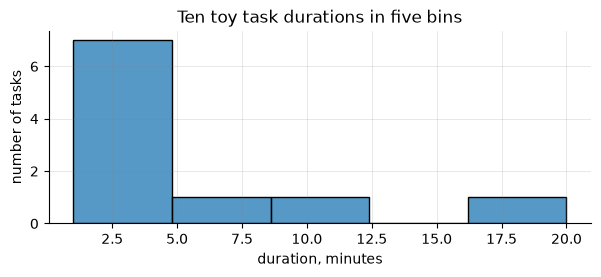

In [11]:
toy_durations = pd.Series([1, 2, 2, 3, 3, 3, 4, 8, 9, 20])

fig, ax = plt.subplots(figsize=(7, 2.5))

sns.histplot(toy_durations, bins=5, ax=ax)
ax.set_title("Ten toy task durations in five bins")
ax.set_xlabel("duration, minutes")
ax.set_ylabel("number of tasks")
make_ax_better(ax)

plt.show()

The range runs from 1 to 20, so five bins are each about 3.8 minutes wide. Count with a finger: the seven values from 1 to 4 fall in the first bin, the 8 alone in the second, the 9 in the third, nothing in the fourth, the 20 in the last. Seven, one, one, zero, one: that is the chart.

Now the real thing: 4,077 task durations in forty bins.

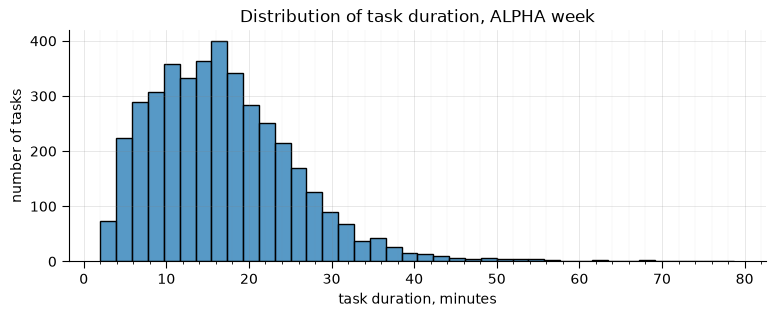

mean 16.9 min   median 15.9 min


In [12]:
fig, ax = plt.subplots(figsize=(9, 3))

sns.histplot(tasks["duration_min"], bins=40, ax=ax)
ax.set_title("Distribution of task duration, ALPHA week")
ax.set_xlabel("task duration, minutes")
ax.set_ylabel("number of tasks")
make_ax_better(ax, minor="x")

plt.show()

print(
    f"mean {tasks['duration_min'].mean():.1f} min   "
    f"median {tasks['duration_min'].median():.1f} min"
)

✅ **What it means:** a mild right tail, and mean and median land within a minute of each other. When the two agree, either number is a fair answer. **Mean is safe here — don't get used to it.**

⛔ **What it does NOT mean:** that "a task takes 16 minutes". Look at the width of that distribution: plenty of tasks take 5 minutes and plenty take 40. **A single number never describes a spread.**

---

## 3. ❓ "How fast do our pickers scan?"

<details>
<summary>🔍 <b>What we'll do</b> — how would you get this from an event log?</summary>

Zoom from tasks down to the picker's micro-rhythm: the seconds between two consecutive events *inside* one task. That means sorting the events inside each task and subtracting each timestamp from the one above it — a **window function**, which is a different animal from `groupby` + `agg`. See the card below.
</details>

`.diff()` is new, so — **toy table first**: six rows we can check by eye.

> 🖼 **The picture for this section** is the window-function card in `concept-cards.html`, in this same folder. Open it next to the notebook: `groupby().agg()` squashes each pile into one row, `groupby().diff()` keeps every row and looks sideways at its neighbour.

In [13]:
toy_scans = pd.DataFrame({
    "task_id": ["A", "A", "A", "B", "B", "B"],
    "event_time": pd.to_datetime([
        "2026-03-02 10:00:00",
        "2026-03-02 10:00:05",   # 5 s after the previous one
        "2026-03-02 10:00:12",   # 7 s
        "2026-03-02 11:30:00",   # new task: no previous row to compare with
        "2026-03-02 11:30:04",   # 4 s
        "2026-03-02 11:30:30",   # 26 s
    ]),
})

toy_scans["gap_s"] = (
    toy_scans
    .groupby("task_id")["event_time"]
    .diff()
    .dt.total_seconds()
)
toy_scans["gap_s_unbounded"] = (
    toy_scans
    ["event_time"]
    .diff()
    .dt.total_seconds()
)
toy_scans

,task_id,event_time,gap_s,gap_s_unbounded
0,A,2026-03-02 10:00:00,NaN,NaN
1,A,2026-03-02 10:00:05,5.0,5.0
2,A,2026-03-02 10:00:12,7.0,7.0
3,B,2026-03-02 11:30:00,NaN,5388.0
4,B,2026-03-02 11:30:04,4.0,4.0
5,B,2026-03-02 11:30:30,26.0,26.0


Read the `gap_s` column: 5, 7 for task A and 4, 26 for task B — exactly what we counted by hand. And **the first row of every task is empty**: there is nothing above it to subtract. That is why `.groupby("task_id")` matters. The second column shows what happens without it: `gap_s_unbounded` compares task B's first scan to task A's last one and reports **5,388 seconds**. That is an hour and a half of "scanning" nobody did. One forgotten `groupby` and the slowest scan in the warehouse is something you invented.

> 🤖 **Ask the assistant.** Ask it to write the gap-per-task computation for `toy_scans` on its own. Compare its answer with ours on the six rows. Same numbers mean the translation is right. The comparison is the check, not the assistant's confidence.

Now the same four steps on 311,543 real events, one action per line. One difference from the toy is deliberate: the gap becomes a **column** of the sorted events table, so later we can group it by anything else the table knows, such as the hour:

In [14]:
# without sorting, every number below would be wrong
events_by_task_time = events.sort_values(["task_id", "event_time"])

# the gap is a column of the table, exactly as in the toy
events_by_task_time["gap_seconds"] = (
    events_by_task_time
    .groupby("task_id")["event_time"]   # gaps inside a task only
    .diff()                             # each row minus the one above
    .dt.total_seconds()                 # timedelta -> plain seconds
)

# for the statistics: one column, without the empty first row of every task
gap_seconds = events_by_task_time["gap_seconds"].dropna()

# two scans with one timestamp would give a zero gap: drop them and say how many
gaps_before = len(gap_seconds)
gap_seconds = gap_seconds[gap_seconds > 0]
print(f"gaps of zero seconds dropped: {gaps_before - len(gap_seconds):,}")

print(
    f"median {gap_seconds.median():.1f} s    "
    f"mean {gap_seconds.mean():.1f} s    "
    f"max {gap_seconds.max():,.0f} s"
)

gaps of zero seconds dropped: 0
median 7.2 s    mean 13.7 s    max 2,635 s


The mean is **double** the median. Something is pulling it up. Look at the distribution as it comes out of the box:

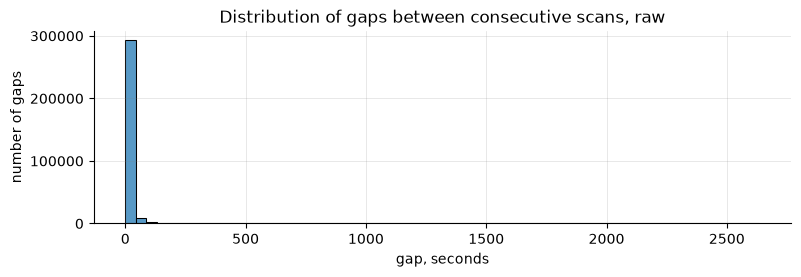

In [15]:
fig, ax = plt.subplots(figsize=(9, 2.5))

sns.histplot(gap_seconds, bins=60, ax=ax)
ax.set_title("Distribution of gaps between consecutive scans, raw")
ax.set_xlabel("gap, seconds")
ax.set_ylabel("number of gaps")
make_ax_better(ax)

plt.show()

**Stop and look at what this chart actually tells you. Nothing.**

I have seen a lot of histograms like this one, and for me it is a reliable sign that whoever drew it — and whoever drew conclusions from it — did not look at their own data. There is one visible bar. The x-axis runs to 2,635 seconds because a handful of points live out there, and those few points set the scale for all 307,306. Every real feature of the distribution is crushed into the first pixel column.

Let's measure the damage instead of guessing at it:

In [16]:
bin_width = gap_seconds.max() / 60          # 60 bins over the full range
in_first_bin = (gap_seconds <= bin_width).mean()

print(f"one bin is {bin_width:.0f} s wide")
print(f"share of all gaps sitting in that single first bar: {in_first_bin:.1%}")

one bin is 44 s wide
share of all gaps sitting in that single first bar: 95.4%


**95% of the data is in one bar.** The chart is not "a bit skewed" — it is blind.

Two standard repairs: cut the axis to the range we care about, or keep every point and stretch the axis logarithmically instead.

On a log axis each step to the right is ×10, not +10: `10⁰` is 1 second, `10¹` is 10, `10²` is 100. The hump sits between the first two, so most gaps are a handful of seconds.

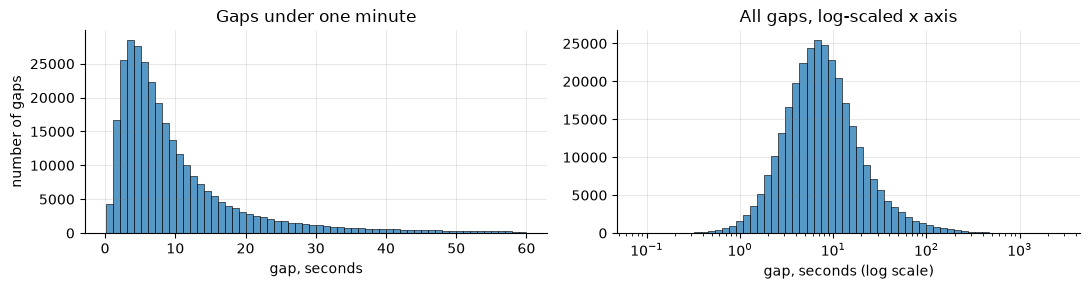

the left chart hides 9,075 gaps of 307,306 (3.0%); the longest was 2,635 s


In [17]:
under_a_minute = gap_seconds[gap_seconds < 60]

fig, axes = plt.subplots(1, 2, figsize=(11, 3))

sns.histplot(under_a_minute, bins=60, ax=axes[0])
axes[0].set_title("Gaps under one minute")
axes[0].set_xlabel("gap, seconds")
axes[0].set_ylabel("number of gaps")

sns.histplot(gap_seconds, bins=60, log_scale=True, ax=axes[1])
axes[1].set_title("All gaps, log-scaled x axis")
axes[1].set_xlabel("gap, seconds (log scale)")
axes[1].set_ylabel("")

for ax in axes:
    make_ax_better(ax)

plt.tight_layout()
plt.show()

# the rule: if you cut something out of a chart, say how much you cut
cut = gap_seconds >= 60
print(
    f"the left chart hides {cut.sum():,} gaps of {len(gap_seconds):,} "
    f"({cut.mean():.1%}); the longest was {gap_seconds.max():,.0f} s"
)

✅ **What it means:** the typical rhythm is a handful of seconds — the zoomed chart finally shows a shape. The log axis keeps every point and shows the shape honestly: one hump around 5–10 seconds, and a thin tail running three orders of magnitude out to 2,635 s (44 minutes — someone walked away). That tail is small in *count* and large in *seconds*, which is exactly why it moves the mean and not the median.

So when the manager asks "how fast do our pickers scan?":

- **median (≈7 s)** — the *typical* scan-to-scan rhythm;
- **mean (≈14 s)** — only if you are budgeting *total* time, because rare long pauses genuinely spend it.

⛔ **What it does NOT mean:** that the long pauses are errors to delete. They are real — people rest, walk far, get interrupted. The tail is **information, not garbage**. It just must not *silently* drive your summary.

**Notice what we did twice now:** every time we cut something out of a chart, we printed how much. Do this always. A chart that hides 3% of the data is fine; a chart that hides 3% *without telling you* is a trap — and most of the time the person who drew it was the first one fooled.

**And notice what the titles say.** "Distribution of gaps between consecutive scans" — what is drawn, not what to think. The conclusion is here, in words, underneath. A chart whose title argues for you stops being evidence and becomes a slogan.



---

## 3b. From gaps to shifts — the same trick, one step further

A gap tells you how long a pause was. A *long* pause tells you something else: the worker went home. That is how you cut an event log into **shifts** without a shift column — and it is exactly the question HW1 will hand you.

The move is two window functions in a row, on the toy first: mark where a new shift starts, then count how many starts happened above each row.

In [18]:
toy_worker = pd.DataFrame({
    "user_id": ["u1", "u1", "u1", "u1", "u2", "u2"],
    "event_time": pd.to_datetime([
        "2026-03-02 09:00:00",
        "2026-03-02 09:40:00",   # 40 min later, same shift
        "2026-03-02 18:00:00",   # 8 h later, clearly a new shift
        "2026-03-02 18:30:00",   # 30 min later, same shift
        "2026-03-02 10:00:00",   # another worker starts fresh
        "2026-03-02 10:20:00",
    ]),
})

# 1) how long since this worker's previous event?
toy_worker["gap_min"] = (
    toy_worker
    .groupby("user_id")["event_time"]
    .diff()
    .dt.total_seconds() / 60
)

# 2) a break longer than 90 minutes means a new shift started here
toy_worker["is_new_shift"] = toy_worker["gap_min"] > 90

# 3) cumsum counts the True's above each row, so it numbers the shifts
toy_worker["shift_no"] = toy_worker.groupby("user_id")["is_new_shift"].cumsum()
toy_worker

,user_id,event_time,gap_min,is_new_shift,shift_no
0,u1,2026-03-02 09:00:00,NaN,False,0
1,u1,2026-03-02 09:40:00,40.0,False,0
2,u1,2026-03-02 18:00:00,500.0,True,1
3,u1,2026-03-02 18:30:00,30.0,False,1
4,u2,2026-03-02 10:00:00,NaN,False,0
5,u2,2026-03-02 10:20:00,20.0,False,0


Read the last column: `u1` has shifts 0 and 1, `u2` has one shift. `cumsum()` on a True/False column is a running count of the `True`s — every time a new shift is flagged, the number ticks up and stays there. It is a window function like `.diff()`: **six rows in, six rows out**.

Two judgement calls are yours, not pandas': the **90 minutes** (why not 60? why not 4 hours?) and whether the first row of a worker — always `NaN`, so `False` — should count as shift 0. Neither has a right answer, which is precisely why this question is worth an assignment.

> ⚠️ **This is a threshold you chose, not a fact you measured.** Say the number out loud in your write-up and show what changes if you move it. A shift boundary that nobody can see is still a decision.

---

## 4. ❓ "What does a typical picked item cost?"

<details>
<summary>🔍 <b>What we'll do</b></summary>

For the finance half of the room: join the picks to the price list and compare mean against median again.
</details>

rows before: 145,904   rows after: 145,904


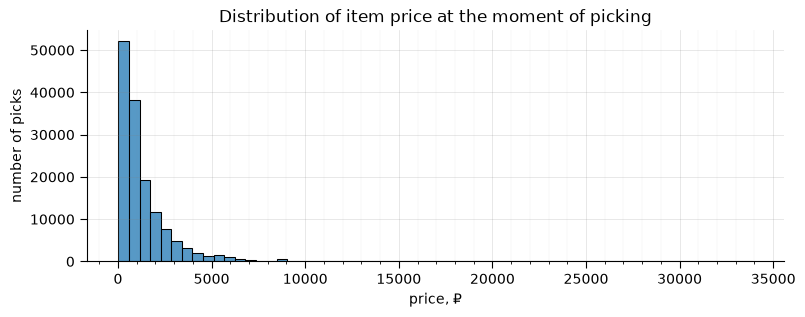

median 834 ₽    mean 1,423 ₽    total value moved 208M ₽


In [19]:
prices = pd.read_parquet(DATA / "item_prices.parquet")
picks_with_price = picks.merge(prices, on="item_id", how="left")
# the habit from session 2: a join must not lose or multiply rows
print(f"rows before: {len(picks):,}   rows after: {len(picks_with_price):,}")

picked_prices = picks_with_price["price"]

fig, ax = plt.subplots(figsize=(9, 3))

sns.histplot(picked_prices, bins=60, ax=ax)
ax.set_title("Distribution of item price at the moment of picking")
ax.set_xlabel("price, ₽")
ax.set_ylabel("number of picks")
make_ax_better(ax, minor="x")

plt.show()

print(
    f"median {picked_prices.median():,.0f} ₽    "
    f"mean {picked_prices.mean():,.0f} ₽    "
    f"total value moved {human_format(picked_prices.sum())} ₽"
)

✅ **What it means:** "average revenue per pick" overstates the *typical* pick by ×1.7. Every **average check** you will ever present has this inside it.

⛔ **What it does NOT mean:** that the mean is wrong. If you need total revenue, the mean is exactly the number to multiply by. Wrong is using it to describe a typical customer.

---

## 5. ❓ "Do our pickers differ a lot in output?"

<details>
<summary>🔍 <b>What we'll do</b></summary>

The contrast case. Count successful picks per worker for the week and look at the shape *before* choosing a summary.
</details>

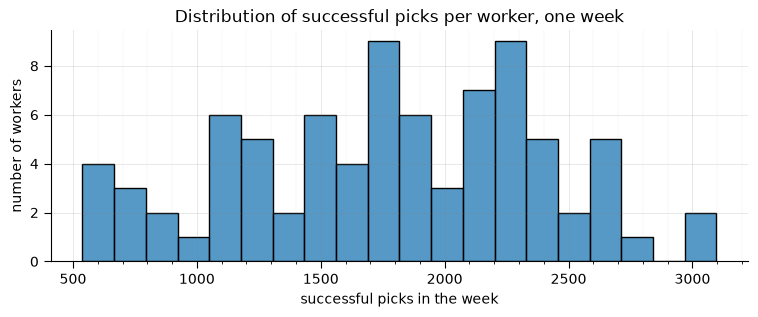

median 1,801    mean 1,779


In [20]:
picks_per_worker = picks.groupby("user_id").size()

fig, ax = plt.subplots(figsize=(9, 3))

sns.histplot(picks_per_worker, bins=20, ax=ax)
ax.set_title("Distribution of successful picks per worker, one week")
ax.set_xlabel("successful picks in the week")
ax.set_ylabel("number of workers")
make_ax_better(ax, minor="x")

plt.show()

print(
    f"median {picks_per_worker.median():,.0f}    "
    f"mean {picks_per_worker.mean():,.0f}"
)

✅ **What it means:** roughly symmetric → mean and median agree, and here the mean is a fair summary. You only know which case you are in **by looking**. That is the whole rule of the evening.

⛔ **What it does NOT mean:** that the workers are interchangeable — the spread still runs from a few hundred picks to several thousand. Agreement of mean and median says the distribution is *balanced*, not *narrow*.

---

## 6. Quantiles — the language of promises

Businesses don't run on averages, they run on **promises**: to clients, to SLAs (service level agreements: promises to a client, such as 9 of 10 tasks within 28 minutes), to the board. Quantiles are how you phrase them. `.quantile(0.9)` returns the value that 90% of the rows sit below; a list inside the brackets asks for several at once.

In [21]:
tasks["duration_min"].quantile([0.5, 0.9, 0.99]).round(1)

0.50    15.9
0.90    27.8
0.99    44.3
Name: duration_min, dtype: float64

Read it as sentences:

- *Half our tasks finish within ~16 minutes* (p50)
- *Nine out of ten finish within ~28* (p90)
- *The worst 1% run past ~44* (p99)

When you hear "on average it's fine", train the follow-up: **"and the p90?"**

In [22]:
print(
    "gap quantiles, s:",
    gap_seconds.quantile([0.5, 0.9, 0.99]).round(0).to_dict()
)

gap quantiles, s: {0.5: 7.0, 0.9: 26.0, 0.99: 120.0}


## 7. Spread: std vs IQR

Same story, one level up: the standard deviation is mean-based, so the tail inflates it too. The **interquartile range** (p75 − p25 — the width of the middle half of the data) shrugs.

In [23]:
iqr_seconds = gap_seconds.quantile(0.75) - gap_seconds.quantile(0.25)

print(
    f"std {gap_seconds.std():.1f} s    "
    f"IQR {iqr_seconds:.1f} s"
)

std 31.8 s    IQR 9.1 s


Pair like with like: **median + IQR** for the typical case, **mean + std** for symmetric data, **quantiles** when tails matter.

---

## 8. What a boxplot actually is

We are about to compare seven sectors at once. Seven histograms would not fit on a slide — so we need the chart that squeezes a whole distribution into one narrow shape: the **boxplot**. It is built from the exact numbers we just computed, so let's take it apart on a **toy** where we can count by hand.

Three names for the same thing: outlier, flier, a dot past the whisker. seaborn's argument is `showfliers`.

> 🖼 **The picture for this section** is card 2 in `concept-cards.html`, in this same folder: the boxplot taken apart, every part labelled with the number it is built from. Open it next to the toy below.

Nine delivery delays, already sorted:

In [24]:
toy_delays = pd.Series([3, 5, 6, 7, 8, 9, 11, 14, 30])

q1 = toy_delays.quantile(0.25)
median = toy_delays.median()
q3 = toy_delays.quantile(0.75)
iqr = q3 - q1

print(f"q1 (25%) = {q1}    median (50%) = {median}    q3 (75%) = {q3}")
print(f"IQR = q3 - q1 = {iqr}")
upper_fence = q3 + 1.5 * iqr
last_inside_fence = toy_delays[toy_delays <= upper_fence].max()
print(f"upper fence = q3 + 1.5 x IQR = {upper_fence}")
print(
    f"the whisker is drawn to the last real point inside the fence: "
    f"{last_inside_fence}"
)

q1 (25%) = 6.0    median (50%) = 8.0    q3 (75%) = 11.0
IQR = q3 - q1 = 5.0
upper fence = q3 + 1.5 x IQR = 18.5
the whisker is drawn to the last real point inside the fence: 14


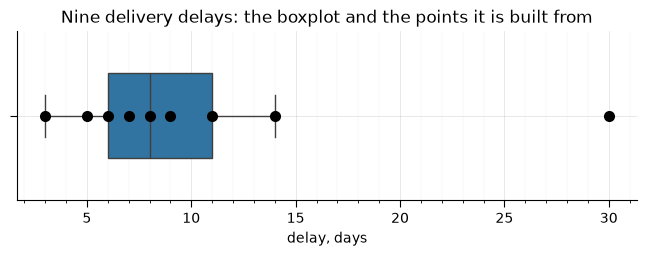

In [25]:
fig, ax = plt.subplots(figsize=(8, 2.2))

sns.boxplot(x=toy_delays, ax=ax, width=0.5)
# the same nine points on top of the box, so you can see where each one went
sns.stripplot(x=toy_delays, ax=ax, color="black", size=8, jitter=False)

ax.set_title("Nine delivery delays: the boxplot and the points it is built from")
ax.set_xlabel("delay, days")
make_ax_better(ax, minor="x")

plt.show()

Match the picture to the numbers:

| Part of the box | What it is | Toy value |
|---|---|---|
| left edge of the box | **q1** — 25% of points are below it | 6 |
| line inside the box | **median** — half below, half above | 8 |
| right edge of the box | **q3** — 75% of points are below it | 11 |
| width of the box | **IQR** — the middle half of your data lives here | 5 |
| whiskers | the **fence** is 1.5 × IQR past the box; the whisker is drawn to the last real point inside it | 14 (the last point inside the 18.5 fence) |
| dots beyond the whisker | individual points, plotted one by one | 30 |

Two things students get wrong about boxplots, so say them out loud:

1. **A dot past the whisker is not an error.** It is one real observation that sits far from the middle. In our warehouse those dots are the 44-minute pauses — the most interesting rows in the table.
2. **The box says nothing about how many points there are.** A box built from 12 tasks looks exactly like a box built from 12,000. If group sizes differ, say so.

**When a boxplot beats a histogram:** when you compare *many groups at once*. One or two distributions → histograms, because they show the *shape*. Five or more → boxes, because histograms stop being readable.

---

## 9. ❓ "Are some sectors slower than others?"

<details>
<summary>🔍 <b>What we'll do</b> — seven groups: which chart, and why?</summary>

Compute picks per hour for each task, label each task with its sector, and compare all seven sectors in one chart. Seven groups is boxplot territory. One check on the way: `.nunique()` counts how many *different* values a group holds. If every task has exactly one sector, the label is exact.
</details>

In [26]:
topology = pd.read_parquet(DATA / "topology.parquet")
picks_located = picks.merge(
    topology[["cell_id", "sector_id"]],
    on="cell_id",
    how="left",
)
print(f"rows before: {len(picks):,}   rows after: {len(picks_located):,}")

# one task, one sector: checked, not assumed
sectors_per_task = picks_located.groupby("task_id")["sector_id"].nunique()
print("sectors per task, max:", sectors_per_task.max())

tasks["sector"] = (
    picks_located
    .groupby("task_id")["sector_id"]
    .first()
    # capital-I Int64 is an integer type that allows empty values
    # (the float ids from session 1)
    .astype("Int64")
    .astype("string")       # a sector id is a label, not a quantity
)
tasks["picks_per_hour"] = tasks["picks"] / (tasks["duration_min"] / 60)

# draw the sectors slowest-first, so the eye reads the trend upward
sector_order = (
    tasks
    .groupby("sector")["picks_per_hour"]
    .median()
    .sort_values()
    .index
)

rows before: 145,904   rows after: 145,904
sectors per task, max: 1


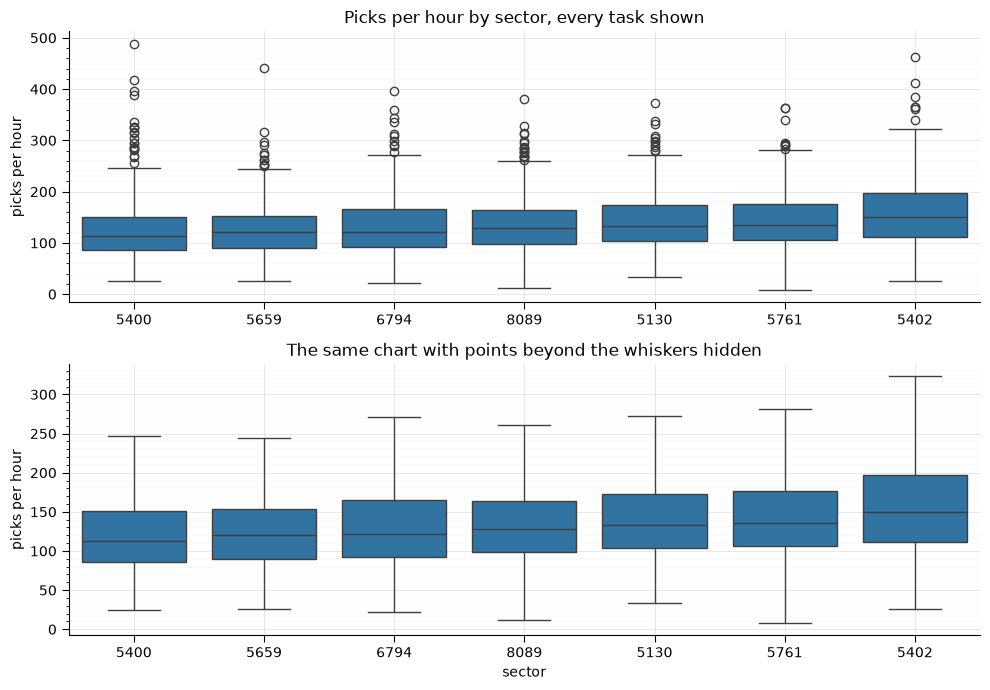

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# every point kept — honest, and unreadable
sns.boxplot(
    data=tasks,
    x="sector",
    y="picks_per_hour",
    order=sector_order,
    ax=axes[0],
)
axes[0].set_title("Picks per hour by sector, every task shown")
axes[0].set_ylabel("picks per hour")
axes[0].set_xlabel("")

# outliers hidden — readable, and it hides something
sns.boxplot(
    data=tasks,
    x="sector",
    y="picks_per_hour",
    order=sector_order,
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("The same chart with points beyond the whiskers hidden")
axes[1].set_ylabel("picks per hour")
axes[1].set_xlabel("sector")

for ax in axes:
    make_ax_better(ax, minor="y")

plt.tight_layout()
plt.show()

In [28]:
# we hid something, so we say how much (the rule from section 2)
q1_by_sector = tasks.groupby("sector")["picks_per_hour"].quantile(0.25)
q3_by_sector = tasks.groupby("sector")["picks_per_hour"].quantile(0.75)
iqr_by_sector = q3_by_sector - q1_by_sector

# .map from session 2: every task gets the fences of its own sector
low_fence = tasks["sector"].map(q1_by_sector - 1.5 * iqr_by_sector)
high_fence = tasks["sector"].map(q3_by_sector + 1.5 * iqr_by_sector)
is_flier = (
    (tasks["picks_per_hour"] < low_fence)
    | (tasks["picks_per_hour"] > high_fence)
)

hidden = is_flier.sum()
print(
    f"the lower chart hides {hidden:,} tasks of {len(tasks):,} "
    f"({hidden / len(tasks):.1%}); the fastest was "
    f"{tasks['picks_per_hour'].max():.0f} picks per hour"
)
tasks.groupby("sector")["picks_per_hour"].median().round(1).sort_values()

the lower chart hides 84 tasks of 4,077 (2.1%); the fastest was 489 picks per hour


sector
5400    113.3
5659    120.9
6794    121.3
8089    128.7
5130    133.5
5761    135.3
5402    149.9
Name: picks_per_hour, dtype: float64

✅ **What it means:** medians run from ~113 to ~150 picks per hour, so the sectors are ordered — and the top chart shows why we had to hide something to see it: 2% of tasks are fast enough to push every box down into the bottom third of the picture. The y-axis was recomputed for the lower panel, and that rescaling is part of why it became readable.

⛔ **What it does NOT mean:** that sector 5400 is "worse" than sector 5402. Look at how far the boxes overlap: most tasks in the slowest sector would be perfectly ordinary in the fastest one. Sectors *look* different — but is that a real difference or the luck of one week? **That question is next session's entire lecture.** Resist the urge to declare a winner tonight.

## Try it yourself

1. Which **hour of day** has the slowest median gap between scans? Is it the night? *(the gap is a column of `events_by_task_time` now, and `.dt.hour` from session 2 gives the hour)*
2. Top-5 most **expensive single picks** of the week — items and prices. *(join, sort, head)*
3. Which sector has the **widest IQR** of picks per hour — steady or chaotic? *(and how many outliers would a boxplot of it hide?)*

In [29]:
# your turn


## ⚡ Extras — power tools, not required

The flier count from section 9 in one chain. `.quantile([0.25, 0.75])` on a group returns both quartiles stacked; `.unstack()` (session 2) turns them into two columns, one row per sector.

In [30]:
quartiles_by_sector = (
    tasks
    .groupby("sector")["picks_per_hour"]
    .quantile([0.25, 0.75])
    .unstack()                  # one row per sector, one column per quartile
)
iqr_by_sector = quartiles_by_sector[0.75] - quartiles_by_sector[0.25]
low_fence = tasks["sector"].map(quartiles_by_sector[0.25] - 1.5 * iqr_by_sector)
high_fence = tasks["sector"].map(quartiles_by_sector[0.75] + 1.5 * iqr_by_sector)
is_flier = (
    (tasks["picks_per_hour"] < low_fence)
    | (tasks["picks_per_hour"] > high_fence)
)
print(f"hidden by the sector boxplot: {is_flier.sum():,} of {len(tasks):,}")

hidden by the sector boxplot: 84 of 4,077


Same numbers as section 9.

## Recap

- **Distribution first, number second** — you can't pick the right summary blind.
- Build an unfamiliar table **in steps**, looking after each one. The one-expression version comes after you trust the pieces, not instead of them.
- Median = the typical case; mean = totals and budgets; skew splits them (gaps: 7 vs 14 s; prices: 834 vs 1,423 ₽).
- The tail is information, not garbage — but it must not silently drive the summary.
- A histogram cuts the range into equal-width **bins** and counts rows in each. One bar holding 95% of the data answers nothing: zoom, or use a log axis.
- **If you cut something out of a chart, say how much you cut.**
- **The title says what is drawn; the conclusion goes underneath, in words.** A chart that argues in its own title stops being evidence.
- Quantiles are promises: p50 / p90 / p99. For spread, std inflates with the tail and IQR doesn't. Pair like with like.
- A boxplot is q1 / median / q3, whiskers to the last point inside 1.5 × IQR, and every far point (outlier, flier) drawn individually — the chart for comparing many groups at once. One or two groups? Use histograms.
- A pickle is any Python object saved to disk; parquet is for tables. Open only pickles you trust.
- Sectors *look* different → "difference or luck?" is next week's question.